# Trening ResNet50 z zastosowaniem preprocessingu

Celem eksperymentu jest określenie, czy zastosowanie metod preprocessingu podczas treningu modelu może zwiększyć jego odporność na zmienne warunki oświetleniowe.

Porównane zostaną trzy konfiguracje:

- obraz oryginalny,
- korekcja gamma,
- CLAHE.

Wszystkie konfiguracje wykorzystują tę samą architekturę `ResNet50`, strategię `WeightedRandomSampler`, rozmiar obrazu wejściowego oraz procedurę treningową.

Model jest najpierw trenowany przy zamrożonym backbone'e, a następnie poddawany fine-tuningowi.

Podstawowym kryterium wyboru konfiguracji jest średnia wartość `Macro F1` uzyskana dla kontrolowanych wariantów zaciemnienia `dark_1`, `dark_2` i `dark_3` na zbiorze walidacyjnym.

Zbiór `test_final` jest wykorzystywany wyłącznie do końcowej oceny wybranej konfiguracji.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
)

from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.preprocessing import (
    build_preprocessing_train_transform,
    build_preprocessing_eval_transform,
)

from src.data.sampling import (
    build_weighted_sampler,
)


from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "preprocessing_analysis"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 5 #10
FINE_TUNE_EPOCHS = 0 #5
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True

PREPROCESSING_METHODS = [
    "original",
    "gamma",
    "clahe",
]


DARK_VARIANTS = [
    "dark_1",
    "dark_2",
    "dark_3",
]


LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
    "bright_1",
    "bright_2",
    "bright_3",
]


print(
    "Metody:",
    PREPROCESSING_METHODS
)

print(
    "Dark variants:",
    DARK_VARIANTS
)

Metody: ['original', 'gamma', 'clahe']
Dark variants: ['dark_1', 'dark_2', 'dark_3']


## 2. Manifesty i mapowanie klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST: 4298


## 3. Funkcja przygotowująca model

Dla każdej metody preprocessingu tworzony jest nowy model ResNet50 z identycznymi wagami początkowymi ImageNet.

Backbone zostaje zamrożony w pierwszym etapie treningu.

In [4]:
def create_frozen_resnet50():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )

    model = (
        freeze_resnet50_backbone(
            model
        )
    )

    model = model.to(
        DEVICE
    )

    return model

## 4. Przygotowanie DataLoaderów dla określonej metody preprocessingu

Zastosowana zostaje ta sama strategia `WeightedRandomSampler` dla wszystkich konfiguracji.

Różnica pomiędzy eksperymentami dotyczy wyłącznie preprocessingu obrazu.

In [5]:
def build_training_loaders(
    preprocessing_method,
):

    train_transform = (
        build_preprocessing_train_transform(
            preprocessing_method,
            image_size=IMAGE_SIZE,
        )
    )

    eval_transform = (
        build_preprocessing_eval_transform(
            preprocessing_method,
            image_size=IMAGE_SIZE,
        )
    )


    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=train_transform,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=eval_transform,
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 5. Funkcja treningu pojedynczej konfiguracji

Każda metoda preprocessingu jest oceniana w dwóch etapach:

1. trening przy zamrożonym backbone,
2. fine-tuning końcowego bloku ResNet50 i głowicy klasyfikacyjnej.

Checkpoint najlepszego modelu jest wybierany na podstawie `validation macro F1`.

In [6]:
def train_preprocessing_configuration(
    preprocessing_method,
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"PREPROCESSING: "
        f"{preprocessing_method}"
    )

    print(
        "=" * 70
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_training_loaders(
        preprocessing_method
    )


    model = (
        create_frozen_resnet50()
    )


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{preprocessing_method}"
            f"_frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{preprocessing_method}"
            f"_finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "model": model,
        "train_dataset": train_dataset,
        "validation_dataset":
            validation_dataset,
        "train_loader":
            train_loader,
        "validation_loader":
            validation_loader,
        "frozen_history":
            frozen_history,
        "finetune_history":
            finetune_history,
    }

## 6. Trening konfiguracji bazowej — obraz oryginalny

In [7]:
original_experiment = (
    train_preprocessing_configuration(
        "original"
    )
)


PREPROCESSING: original


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu: 0it [00:00, ?it/s]

## 7. Trening konfiguracji z korekcją gamma

In [8]:
gamma_experiment = (
    train_preprocessing_configuration(
        "gamma"
    )
)


PREPROCESSING: gamma


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu: 0it [00:00, ?it/s]

## 8. Trening konfiguracji z CLAHE

In [9]:
clahe_experiment = (
    train_preprocessing_configuration(
        "clahe"
    )
)


PREPROCESSING: clahe


Postęp treningu:   0%|          | 0/5 [00:00<?, ?it/s]

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

Postęp treningu: 0it [00:00, ?it/s]

## 9. Podstawowa skuteczność modeli na zbiorze walidacyjnym

Najpierw porównywana jest skuteczność poszczególnych konfiguracji dla niezmodyfikowanego zbioru walidacyjnego.

In [10]:
experiments = {
    "original": original_experiment,
    "gamma": gamma_experiment,
    "clahe": clahe_experiment,
}


validation_results = []


for method, experiment in experiments.items():

    model = experiment[
        "model"
    ]

    loader = experiment[
        "validation_loader"
    ]


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    validation_results.append(
        {
            "method": method,
            "accuracy": metrics[
                "accuracy"
            ],
            "macro_precision":
                metrics[
                    "macro_precision"
                ],
            "macro_recall":
                metrics[
                    "macro_recall"
                ],
            "macro_f1": metrics[
                "macro_f1"
            ],
            "inference_time_seconds":
                inference_time,
        }
    )


validation_results_df = (
    pd.DataFrame(
        validation_results
    )
)


display(
    validation_results_df
)

,method,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,0.855494,0.842021,0.850918,0.833493,185.980486
1,gamma,0.857882,0.836958,0.847132,0.829204,182.551521
2,clahe,0.812500,0.781680,0.818505,0.783702,195.625847


## 10. Odporność modeli na kontrolowane zaciemnienie

Każda konfiguracja jest oceniana na tych samych kontrolowanych wariantach zaciemnienia:

- `dark_1`,
- `dark_2`,
- `dark_3`.

Dla każdego poziomu zachowana zostaje oryginalna etykieta klasy.

In [11]:
def evaluate_model_on_lighting(
    model,
    preprocessing_method,
    variant,
):

    transform = (
        build_preprocessing_eval_transform(
            preprocessing_method,
            image_size=IMAGE_SIZE,
        )
    )


    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "method":
            preprocessing_method,

        "variant":
            variant,

        "factor":
            LIGHTING_FACTORS[
                variant
            ],

        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

In [12]:
lighting_results = []


for method, experiment in experiments.items():

    model = experiment[
        "model"
    ]


    for variant in [
        "original",
        "dark_1",
        "dark_2",
        "dark_3",
    ]:

        print(
            f"Metoda: {method} | "
            f"Wariant: {variant}"
        )


        result = (
            evaluate_model_on_lighting(
                model=model,
                preprocessing_method=method,
                variant=variant,
            )
        )


        lighting_results.append(
            result
        )


lighting_results_df = (
    pd.DataFrame(
        lighting_results
    )
)


display(
    lighting_results_df
)

Metoda: original | Wariant: original
Metoda: original | Wariant: dark_1
Metoda: original | Wariant: dark_2
Metoda: original | Wariant: dark_3
Metoda: gamma | Wariant: original
Metoda: gamma | Wariant: dark_1
Metoda: gamma | Wariant: dark_2
Metoda: gamma | Wariant: dark_3
Metoda: clahe | Wariant: original
Metoda: clahe | Wariant: dark_1
Metoda: clahe | Wariant: dark_2
Metoda: clahe | Wariant: dark_3


,method,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,original,1.0,2512,0.855494,0.842021,0.850918,0.833493,184.532273
1,original,dark_1,0.7,2512,0.847532,0.828919,0.837860,0.822095,181.600908
2,original,dark_2,0.5,2512,0.832404,0.795100,0.817985,0.792250,187.663165
3,original,dark_3,0.3,2512,0.796178,0.769021,0.790056,0.755763,185.082118
4,gamma,original,1.0,2512,0.857882,0.836958,0.847132,0.829204,184.283726
5,gamma,dark_1,0.7,2512,0.860669,0.837560,0.842390,0.825787,188.773023
6,gamma,dark_2,0.5,2512,0.845939,0.823844,0.826108,0.811690,196.217596
7,gamma,dark_3,0.3,2512,0.831210,0.812971,0.812284,0.795795,197.937577
8,clahe,original,1.0,2512,0.812500,0.781680,0.818505,0.783702,205.278251
9,clahe,dark_1,0.7,2512,0.813694,0.783729,0.817004,0.783891,212.101083


## 11. Średnia skuteczność dla warunków zaciemnienia

Jako główne kryterium porównania konfiguracji przyjęto średnią wartość `macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3`.

Dodatkowo analizowana jest najniższa wartość `macro F1` uzyskana przy najsilniejszym zaciemnieniu.

In [13]:
original_values = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "original"
    ][
        [
            "method",
            "macro_f1",
        ]
    ]
    .set_index(
        "method"
    )
    .rename(
        columns={
            "macro_f1":
                "original_macro_f1"
        }
    )
)


dark3_values = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "dark_3"
    ][
        [
            "method",
            "macro_f1",
        ]
    ]
    .set_index(
        "method"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


dark_summary = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .groupby(
        "method"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .join(
        dark3_values
    )
    .join(
        original_values
    )
)


dark_summary[
    "f1_drop_original_to_dark3"
] = (
    dark_summary[
        "original_macro_f1"
    ]
    -
    dark_summary[
        "dark3_macro_f1"
    ]
)


dark_summary = (
    dark_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    dark_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_original_to_dark3
method,,,,,
gamma,0.811091,0.845939,0.795795,0.829204,0.033409
original,0.790036,0.825372,0.755763,0.833493,0.077730
clahe,0.745886,0.770170,0.688971,0.783702,0.094731


In [14]:
dark3_values = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "dark_3"
    ][
        [
            "method",
            "macro_f1",
        ]
    ]
    .set_index(
        "method"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


dark_summary = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .groupby(
        "method"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
    .join(
        dark3_values
    )
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    dark_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1
method,,,
gamma,0.811091,0.845939,0.795795
original,0.790036,0.825372,0.755763
clahe,0.745886,0.770170,0.688971


## 12. Porównanie konfiguracji dla różnych poziomów zaciemnienia

variant,dark_1,dark_2,dark_3
method,,,
clahe,0.783891,0.764796,0.688971
gamma,0.825787,0.811690,0.795795
original,0.822095,0.792250,0.755763


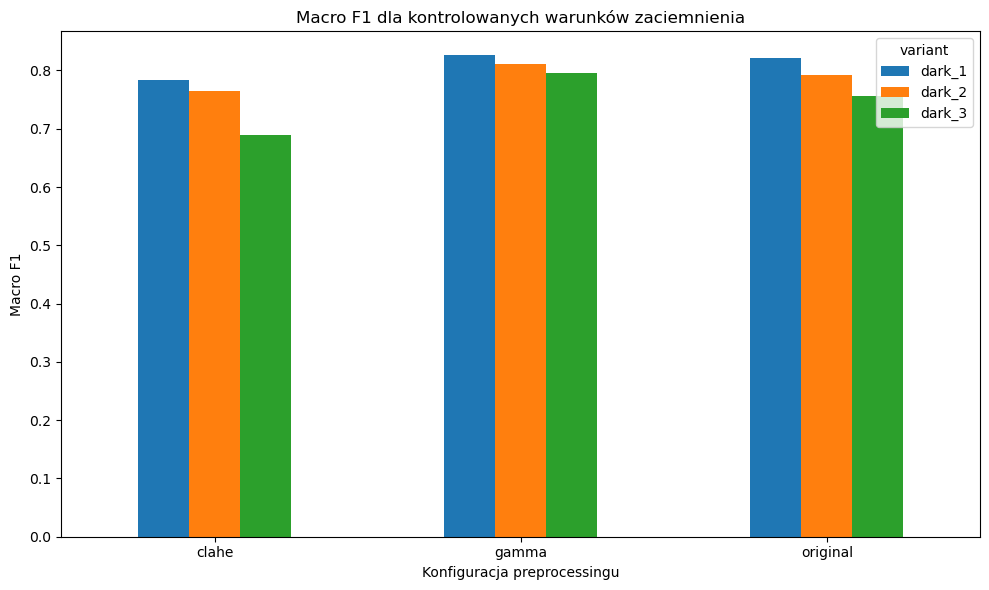

In [15]:
dark_plot = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="method",
        columns="variant",
        values="macro_f1",
    )
    .reindex(
        columns=[
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    kind="bar",
    ax=ax,
)


ax.set_title(
    "Macro F1 dla kontrolowanych warunków zaciemnienia"
)

ax.set_xlabel(
    "Konfiguracja preprocessingu"
)

ax.set_ylabel(
    "Macro F1"
)


plt.xticks(
    rotation=0
)

plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_training_preprocessing_dark_comparison.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 13. Kontrola wpływu preprocessingu na warunki standardowe

Oprócz odporności na zaciemnienie analizowana jest skuteczność konfiguracji dla obrazu oryginalnego.

Pozwala to określić, czy poprawa odporności na niekorzystne oświetlenie odbywa się kosztem skuteczności w standardowych warunkach.

In [16]:
standard_results = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "original"
    ]
    [
        [
            "method",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
        ]
    ]
)


display(
    standard_results
)

,method,accuracy,macro_precision,macro_recall,macro_f1
0,original,0.855494,0.842021,0.850918,0.833493
4,gamma,0.857882,0.836958,0.847132,0.829204
8,clahe,0.812500,0.781680,0.818505,0.783702


## 14. Kontrola warunków zwiększonej jasności

Wyniki dla zwiększonej jasności stanowią dodatkową kontrolę wpływu preprocessingu na obrazy, które nie należą do głównego obszaru badania dotyczącego zaciemnienia.

In [17]:
bright_results = (
    []
)


for method, experiment in experiments.items():

    model = experiment[
        "model"
    ]


    for variant in [
        "bright_1",
        "bright_2",
        "bright_3",
    ]:

        result = (
            evaluate_model_on_lighting(
                model=model,
                preprocessing_method=method,
                variant=variant,
            )
        )


        bright_results.append(
            result
        )


bright_results_df = (
    pd.DataFrame(
        bright_results
    )
)


display(
    bright_results_df
)

,method,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,bright_1,1.3,2512,0.844745,0.840038,0.842052,0.823996,188.700114
1,original,bright_2,1.6,2512,0.826035,0.817780,0.821095,0.799129,185.217333
2,original,bright_3,2.0,2512,0.798965,0.784824,0.789809,0.760735,204.203082
3,gamma,bright_1,1.3,2512,0.840764,0.834140,0.837314,0.817238,198.718372
4,gamma,bright_2,1.6,2512,0.822054,0.810301,0.817639,0.794708,193.208748
5,gamma,bright_3,2.0,2512,0.796178,0.777127,0.791272,0.761504,196.460884
6,clahe,bright_1,1.3,2512,0.798169,0.772170,0.792434,0.761484,206.902742
7,clahe,bright_2,1.6,2512,0.781051,0.761267,0.776440,0.745080,219.433530
8,clahe,bright_3,2.0,2512,0.756369,0.726184,0.749734,0.708688,199.580758


## 15. Wybór konfiguracji

Konfiguracja jest wybierana na podstawie najwyższej średniej wartości `macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3`.

Wyniki dla obrazu oryginalnego oraz zwiększonej jasności są wykorzystywane jako kryteria kontrolne.

In [18]:
best_preprocessing = (
    dark_summary.index[0]
)


print(
    "Najlepsza konfiguracja:",
    best_preprocessing
)

print(
    "\nSzczegóły wybranej konfiguracji:"
)

display(
    dark_summary.loc[
        [best_preprocessing]
    ]
)

Najlepsza konfiguracja: gamma

Szczegóły wybranej konfiguracji:


,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1
method,,,
gamma,0.811091,0.845939,0.795795


In [19]:
all_validation_results = pd.concat(
    [
        lighting_results_df,
        bright_results_df,
    ],
    ignore_index=True,
)


all_validation_results.to_csv(
    METRICS_DIR
    / "trained_preprocessing_lighting_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


dark_summary.to_csv(
    METRICS_DIR
    / "trained_preprocessing_dark_summary.csv",
    encoding="utf-8-sig",
)


selection = {
    "selected_preprocessing":
        best_preprocessing,

    "selection_metric":
        "mean_dark_macro_f1",

    "results":
        dark_summary.reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "trained_preprocessing_selection.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "selected_preprocessing": "gamma",
  "selection_metric": "mean_dark_macro_f1",
  "results": [
    {
      "method": "gamma",
      "mean_dark_macro_f1": 0.8110908700531466,
      "mean_dark_accuracy": 0.8459394904458599,
      "dark3_macro_f1": 0.795795267279455
    },
    {
      "method": "original",
      "mean_dark_macro_f1": 0.7900360042999326,
      "mean_dark_accuracy": 0.825371549893843,
      "dark3_macro_f1": 0.7557630267288665
    },
    {
      "method": "clahe",
      "mean_dark_macro_f1": 0.7458861337638093,
      "mean_dark_accuracy": 0.7701698513800425,
      "dark3_macro_f1": 0.6889712276348454
    }
  ]
}


## 16. Wizualizacja porównania konfiguracji

Porównanie wyników pozwala określić, czy zastosowanie preprocessingu podczas treningu zmienia odporność modelu na kontrolowane zaciemnienie.

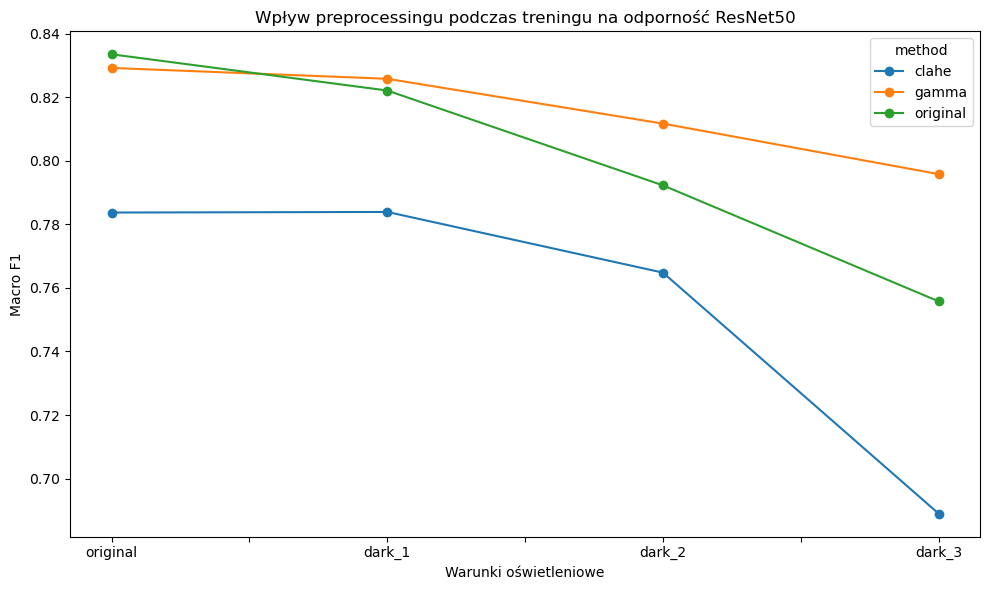

In [20]:
comparison_plot = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "original",
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="variant",
        columns="method",
        values="macro_f1",
    )
    .reindex(
        [
            "original",
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


comparison_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Wpływ preprocessingu podczas treningu "
    "na odporność ResNet50"
)

ax.set_xlabel(
    "Warunki oświetleniowe"
)

ax.set_ylabel(
    "Macro F1"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_trained_preprocessing_robustness.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 17. Końcowa ocena wybranej konfiguracji na `test_final`

Po zakończeniu wyboru konfiguracji na podstawie wyników walidacyjnych przeprowadzana jest końcowa ocena wybranego pipeline'u na niezależnym zbiorze `test_final`.

Zbiór testowy nie był wykorzystywany do wyboru metody preprocessingu.

In [21]:
selected_model = (
    experiments[
        best_preprocessing
    ][
        "model"
    ]
)


selected_transform = (
    build_preprocessing_eval_transform(
        best_preprocessing,
        image_size=IMAGE_SIZE,
    )
)


test_dataset = (
    TrafficSignDataset(
        TEST_PATH,
        class_to_idx,
        transform=selected_transform,
    )
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)


test_true, test_pred, test_time = (
    predict(
        selected_model,
        test_loader,
        DEVICE,
    )
)


test_metrics = evaluate_predictions(
    test_true,
    test_pred,
)


final_results = {
    "model": "ResNet50",

    "preprocessing":
        best_preprocessing,

    "balancing_strategy":
        "weighted_sampler",

    "accuracy":
        test_metrics[
            "accuracy"
        ],

    "macro_precision":
        test_metrics[
            "macro_precision"
        ],

    "macro_recall":
        test_metrics[
            "macro_recall"
        ],

    "macro_f1":
        test_metrics[
            "macro_f1"
        ],

    "test_samples":
        len(test_dataset),

    "inference_time_seconds":
        test_time,
}


print(
    json.dumps(
        final_results,
        indent=2,
    )
)

{
  "model": "ResNet50",
  "preprocessing": "gamma",
  "balancing_strategy": "weighted_sampler",
  "accuracy": 0.8080502559329921,
  "macro_precision": 0.7862710670227907,
  "macro_recall": 0.7980497362616994,
  "macro_f1": 0.7779898606467037,
  "test_samples": 4298,
  "inference_time_seconds": 326.11531019999893
}


## 18. Końcowy raport klasowy

In [23]:
from sklearn.metrics import classification_report

target_names = [
    idx_to_class[index]
    for index in range(
        len(class_codes)
    )
]


test_report = pd.DataFrame(
    classification_report(
        test_true,
        test_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
).T


test_report.to_csv(
    METRICS_DIR
    / "trained_preprocessing_test_final_per_class.csv",
    encoding="utf-8-sig",
)


display(
    test_report
)

,precision,recall,f1-score,support
A-1,0.360000,0.180000,0.240000,50.00000
A-11,1.000000,0.818182,0.900000,11.00000
A-11a,0.750000,0.900000,0.818182,10.00000
A-12a,0.447368,0.809524,0.576271,21.00000
A-14,0.583333,0.636364,0.608696,11.00000
...,...,...,...,...
G-1a,1.000000,1.000000,1.000000,11.00000
G-3,1.000000,1.000000,1.000000,5.00000
accuracy,0.808050,0.808050,0.808050,0.80805
macro avg,0.786271,0.798050,0.777990,4298.00000


In [24]:
(
    METRICS_DIR
    / "trained_preprocessing_test_final.json"
).write_text(
    json.dumps(
        final_results,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


316

## 19. Porównanie z bazowym ResNet50

Wynik finalnego pipeline'u jest zestawiany z bazowym ResNet50 wykorzystującym obrazy bez dodatkowego preprocessingu.

Porównanie pozwala określić, czy zastosowanie preprocessingu podczas treningu i późniejszej klasyfikacji przyniosło poprawę jakości lub odporności modelu.

In [25]:
baseline_path = (
    METRICS_DIR
    / "architecture_final_test.json"
)


if baseline_path.exists():

    baseline = json.loads(
        baseline_path.read_text(
            encoding="utf-8"
        )
    )


    final_comparison = pd.DataFrame(
        [
            {
                "configuration":
                    "ResNet50 + original",

                "accuracy":
                    baseline[
                        "accuracy"
                    ],

                "macro_f1":
                    baseline[
                        "macro_f1"
                    ],
            },

            {
                "configuration":
                    (
                        "ResNet50 + "
                        + best_preprocessing
                    ),

                "accuracy":
                    final_results[
                        "accuracy"
                    ],

                "macro_f1":
                    final_results[
                        "macro_f1"
                    ],
            },
        ]
    )


    display(
        final_comparison
    )


    final_comparison.to_csv(
        METRICS_DIR
        / "final_preprocessing_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )

else:

    print(
        "Nie znaleziono bazowego "
        "wyniku ResNet50."
    )

,configuration,accuracy,macro_f1
0,ResNet50 + original,0.900186,0.88298
1,ResNet50 + gamma,0.808050,0.77799
